<a href="https://colab.research.google.com/github/AkhilKrishna016/fake-news-detection-ml/blob/main/fake_news_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Fake News Detection using Machine Learning

 **Model 1: Logistic Regressionn**

In [11]:
import pandas as pd
import numpy as np
np.random.seed(42)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [12]:
import pandas as pd

df = pd.read_csv("/content/sample_data/fake_and_real_news_dataset.csv")

df.head()

,idd,title,text,label
0,Fq+C96tcx+,‘A target on Roe v. Wade ’: Oklahoma bill maki...,UPDATE: Gov. Fallin vetoed the bill on Friday....,REAL
1,bHUqK!pgmv,Study: women had to drive 4 times farther afte...,Ever since Texas laws closed about half of the...,REAL
2,4Y4Ubf%aTi,"Trump, Clinton clash in dueling DC speeches","Donald Trump and Hillary Clinton, now at the s...",REAL
3,_CoY89SJ@K,Grand jury in Texas indicts activists behind P...,A Houston grand jury investigating criminal al...,REAL
4,+rJHoRQVLe,"As Reproductive Rights Hang In The Balance, De...",WASHINGTON -- Forty-three years after the Supr...,REAL


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4594 entries, 0 to 4593
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   idd     4594 non-null   object
 1   title   4593 non-null   object
 2   text    4594 non-null   object
 3   label   4594 non-null   object
dtypes: object(4)
memory usage: 143.7+ KB


In [14]:
X = df['text']
y = df['label']

In [15]:
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)

X = vectorizer.fit_transform(X)

In [16]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [17]:
# 80-20
model_80 = LogisticRegression()
model_80.fit(X_train_80, y_train_80)

LogisticRegression()

In [18]:
# ---------- 80-20 ----------

predictions_80 = model_80.predict(X_test_80)

accuracy_80 = accuracy_score(y_test_80, predictions_80)

print("Logistic Regression Accuracy (80-20):", accuracy_80)

Logistic Regression Accuracy (80-20): 0.9085963003264418


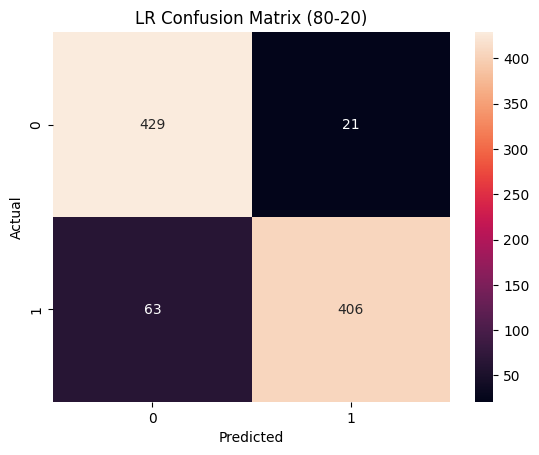

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_80 = confusion_matrix(y_test_80, predictions_80)

sns.heatmap(cm_80, annot=True, fmt='d')
plt.title("LR Confusion Matrix (80-20)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [20]:
# ---------- 70-30 ----------

model_70 = LogisticRegression()
model_70.fit(X_train_70, y_train_70)

predictions_70 = model_70.predict(X_test_70)

accuracy_70 = accuracy_score(y_test_70, predictions_70)

print("Logistic Regression Accuracy (70-30):", accuracy_70)

Logistic Regression Accuracy (70-30): 0.902102973168963


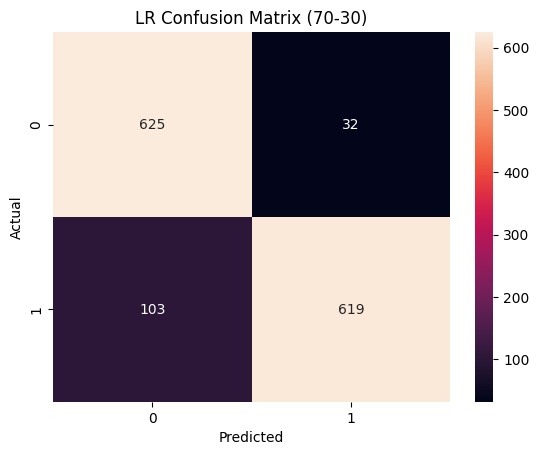

In [21]:
cm_70 = confusion_matrix(y_test_70, predictions_70)

sns.heatmap(cm_70, annot=True, fmt='d')
plt.title("LR Confusion Matrix (70-30)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**## Model 2: Support Vector Machine (SVM)**


In [22]:
# ================= Support Vector Machine =================

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

SVM Accuracy (80-20): 0.9292709466811752


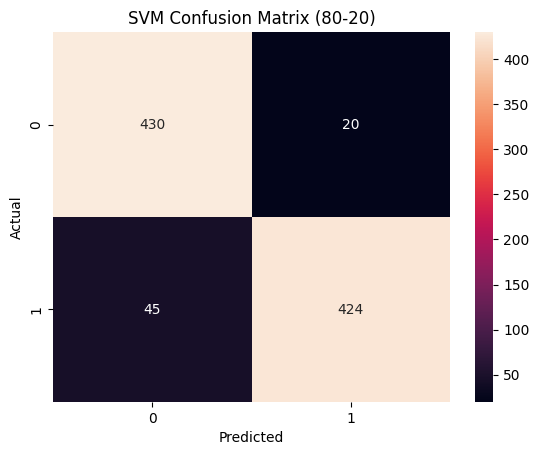

In [23]:
# ---------- 80-20 ----------
svm_80 = LinearSVC()
svm_80.fit(X_train_80, y_train_80)

pred_svm_80 = svm_80.predict(X_test_80)

print("SVM Accuracy (80-20):", accuracy_score(y_test_80, pred_svm_80))

cm_svm_80 = confusion_matrix(y_test_80, pred_svm_80)

sns.heatmap(cm_svm_80, annot=True, fmt='d')
plt.title("SVM Confusion Matrix (80-20)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

SVM Accuracy (70-30): 0.9245830311820159


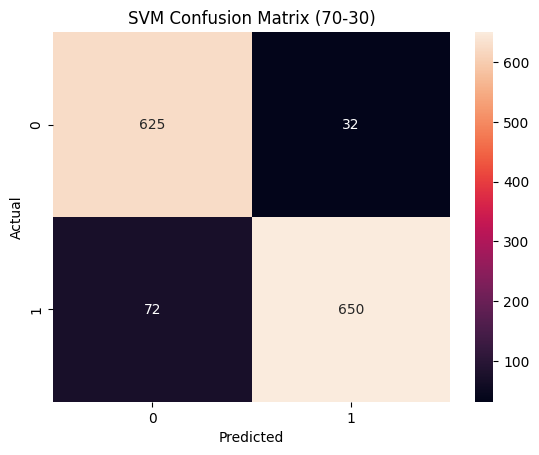

In [24]:

# ---------- 70-30 ----------
svm_70 = LinearSVC()
svm_70.fit(X_train_70, y_train_70)

pred_svm_70 = svm_70.predict(X_test_70)

print("SVM Accuracy (70-30):", accuracy_score(y_test_70, pred_svm_70))

cm_svm_70 = confusion_matrix(y_test_70, pred_svm_70)

sns.heatmap(cm_svm_70, annot=True, fmt='d')
plt.title("SVM Confusion Matrix (70-30)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Model 3: Decision Tree Classifier**


In [25]:
# ================= Decision Tree =================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

Decision Tree Accuracy (80-20): 0.8291621327529923


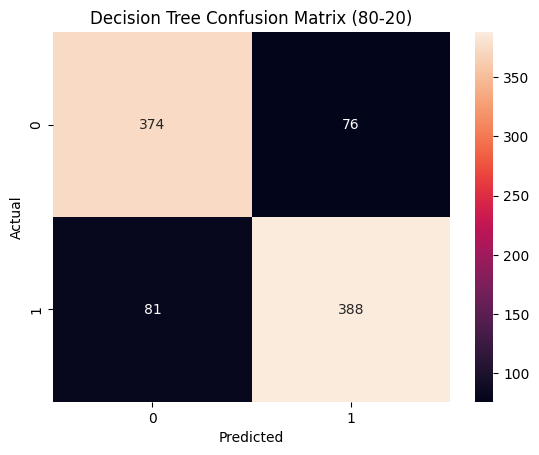

In [26]:
# ---------- 80-20 ----------
dt_80 = DecisionTreeClassifier(random_state=42)
dt_80.fit(X_train_80, y_train_80)

pred_dt_80 = dt_80.predict(X_test_80)

print("Decision Tree Accuracy (80-20):", accuracy_score(y_test_80, pred_dt_80))

cm_dt_80 = confusion_matrix(y_test_80, pred_dt_80)

sns.heatmap(cm_dt_80, annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix (80-20)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



Decision Tree Accuracy (70-30): 0.8201595358955766


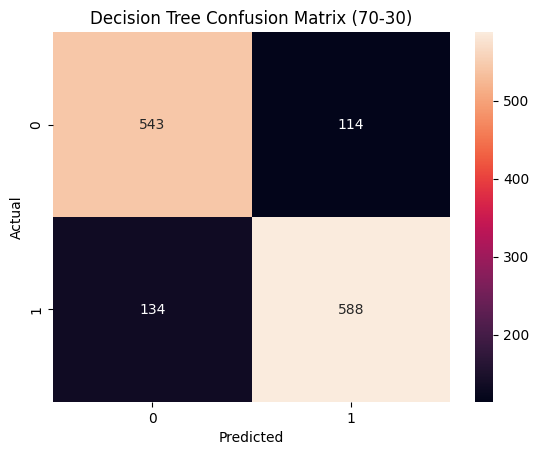

In [27]:
# ---------- 70-30 ----------
dt_70 = DecisionTreeClassifier(random_state=42)
dt_70.fit(X_train_70, y_train_70)

pred_dt_70 = dt_70.predict(X_test_70)

print("Decision Tree Accuracy (70-30):", accuracy_score(y_test_70, pred_dt_70))

cm_dt_70 = confusion_matrix(y_test_70, pred_dt_70)

sns.heatmap(cm_dt_70, annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix (70-30)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Model 4: NAVIE BAYES

In [30]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score

data = pd.read_csv("/content/sample_data/fake_and_real_news_dataset.csv")

data = pd.get_dummies(data)
x = data.iloc[:, :-1]
y = data.iloc[:, -1]

# 80:20 split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

model = GaussianNB()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Naive Bayes 80:20")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


# 70:30 split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Naive Bayes 70:30")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Naive Bayes 80:20
Accuracy: 1.0
[[450   0]
 [  0 469]]
Naive Bayes 70:30
Accuracy: 1.0
[[695   0]
 [  0 684]]


Model 5:RAndom Forest

In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

data = pd.read_csv("/content/sample_data/fake_and_real_news_dataset.csv")

data = pd.get_dummies(data)
x = data.iloc[:, :-1]
y = data.iloc[:, -1]

# 80:20
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Random Forest 80:20")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


# 70:30
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Random Forest 70:30")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Random Forest 80:20
Accuracy: 1.0
[[461   0]
 [  0 458]]
Random Forest 70:30
Accuracy: 1.0
[[675   0]
 [  0 704]]


Model 6: KNN

In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

data = pd.read_csv("/content/sample_data/fake_and_real_news_dataset.csv")

data = pd.get_dummies(data)
x = data.iloc[:, :-1]
y = data.iloc[:, -1]

# 80:20
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("KNN 80:20")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


# 70:30
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("KNN 70:30")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

KNN 80:20
Accuracy: 1.0
[[458   0]
 [  0 461]]
KNN 70:30
Accuracy: 1.0
[[697   0]
 [  0 682]]


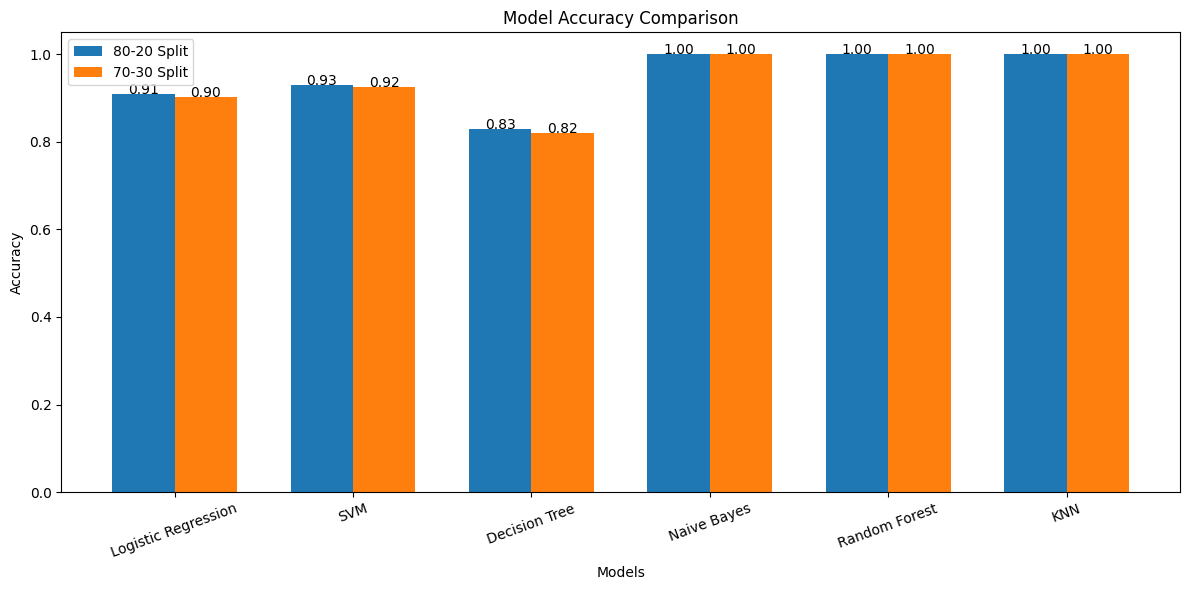

In [33]:
#final accuracy
import matplotlib.pyplot as plt
import numpy as np

models = [
    "Logistic Regression",
    "SVM",
    "Decision Tree",
    "Naive Bayes",
    "Random Forest",
    "KNN"
]

acc_80 = [0.9086, 0.9293, 0.8291, 1.0, 1.0, 1.0]
acc_70 = [0.9021, 0.9246, 0.8201, 1.0, 1.0, 1.0]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, acc_80, width, label='80-20 Split')
plt.bar(x + width/2, acc_70, width, label='70-30 Split')

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(x, models, rotation=20)
plt.legend()

for i in range(len(models)):
    plt.text(i - width/2, acc_80[i], f"{acc_80[i]:.2f}", ha='center')
    plt.text(i + width/2, acc_70[i], f"{acc_70[i]:.2f}", ha='center')

plt.tight_layout()
plt.show()